In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('data/kc_house_data.csv')

In [3]:
print("Data Info:")
print(df.info())
print("\nFirst 5 rows:")

print(df.head())

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [4]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [5]:
df.drop('id', axis=1, inplace=True)

In [6]:
df['date'] = pd.to_datetime(df['date'])
df['year_sold'] = df['date'].dt.year
df['month_sold'] = df['date'].dt.month
df.drop('date', axis=1, inplace=True)

In [7]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
year_sold        0
month_sold       0
dtype: int64


In [8]:

corr_matrix = df.corr()
price_corr = corr_matrix['price'].sort_values(ascending=False)
print("\nCorrelations with Price:")
print(price_corr)


Correlations with Price:
price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
year_sold        0.003576
month_sold      -0.010081
zipcode         -0.053203
Name: price, dtype: float64


In [9]:
key_features = price_corr.index[1:6].tolist()
print(f"\nTop 5 Key Features: {key_features}")


Top 5 Key Features: ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms']


In [10]:
plt.figure(figsize=(16, 12))

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

Text(0.5, 1.0, 'Price Distribution')

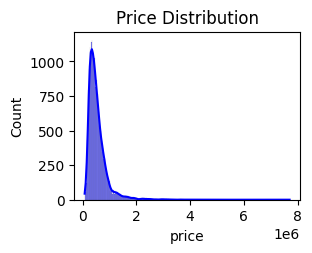

In [11]:
plt.subplot(2, 2, 1)
sns.histplot(df['price'], kde=True, color='blue')
plt.title('Price Distribution')

Text(0.5, 1.0, 'Correlation Heatmap (Key Features)')

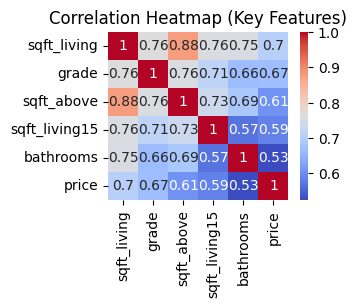

In [12]:
plt.subplot(2, 2, 2)
sns.heatmap(df[key_features + ['price']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Key Features)')

Text(0.5, 1.0, 'Living Area vs Price')

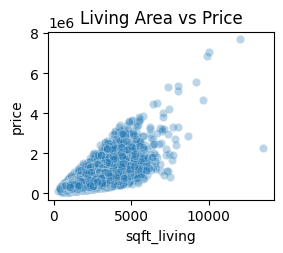

In [13]:
plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='sqft_living', y='price', alpha=0.3)
plt.title('Living Area vs Price')

Text(0.5, 1.0, 'House Grade vs Price')

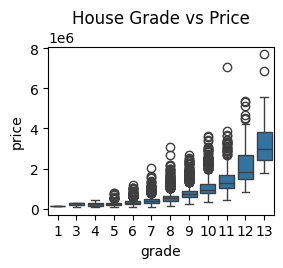

In [14]:
plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='grade', y='price')
plt.title('House Grade vs Price')

In [15]:
plt.tight_layout()
plt.savefig('housing_analysis_dashboard.png')

<Figure size 640x480 with 0 Axes>

In [16]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"\nNumber of outliers detected in price: {len(outliers)}")


Number of outliers detected in price: 1146


In [17]:
df.to_csv('cleaned_housing_data.csv', index=False)